In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# TensorFlow / Keras Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.callbacks import EarlyStopping

### Data Exploration and Preprocessing

In [2]:
df = pd.read_csv('Alphabets_data.csv')
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [4]:
print("Shape of data: ",df.shape)

Shape of data:  (20000, 17)


In [5]:
df.isnull().sum()

letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64

In [6]:
# Check duplicates
df.duplicated().sum()

np.int64(1332)

Duplicate rows were detected but not removed, as the assignment does not require duplicate handling and the dataset is a standard benchmark dataset.

In [7]:
print("Number of unique classes:", df['letter'].nunique())
print("\nClass distribution:")
print(df['letter'].value_counts())

Number of unique classes: 26

Class distribution:
letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
xbox,20000.0,4.02355,1.913212,0.0,3.0,4.0,5.0,15.0
ybox,20000.0,7.03550,3.304555,0.0,5.0,7.0,9.0,15.0
width,20000.0,5.12185,2.014573,0.0,4.0,5.0,6.0,15.0
height,20000.0,5.37245,2.261390,0.0,4.0,6.0,7.0,15.0
onpix,20000.0,3.50585,2.190458,0.0,2.0,3.0,5.0,15.0
xbar,20000.0,6.89760,2.026035,0.0,6.0,7.0,8.0,15.0
ybar,20000.0,7.50045,2.325354,0.0,6.0,7.0,9.0,15.0
x2bar,20000.0,4.62860,2.699968,0.0,3.0,4.0,6.0,15.0
y2bar,20000.0,5.17865,2.380823,0.0,4.0,5.0,7.0,15.0
xybar,20000.0,8.28205,2.488475,0.0,7.0,8.0,10.0,15.0


In [9]:
# Separate features and target
X = df.drop('letter', axis=1)
y = df['letter']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20000, 16)
Target shape: (20000,)


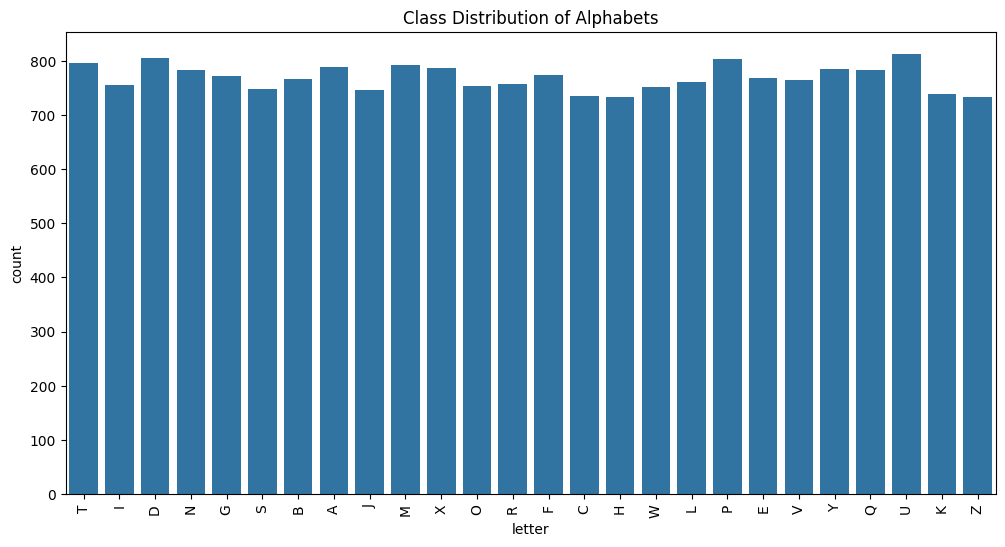

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(x='letter', data=df)
plt.title("Class Distribution of Alphabets")
plt.xticks(rotation=90)
plt.show()

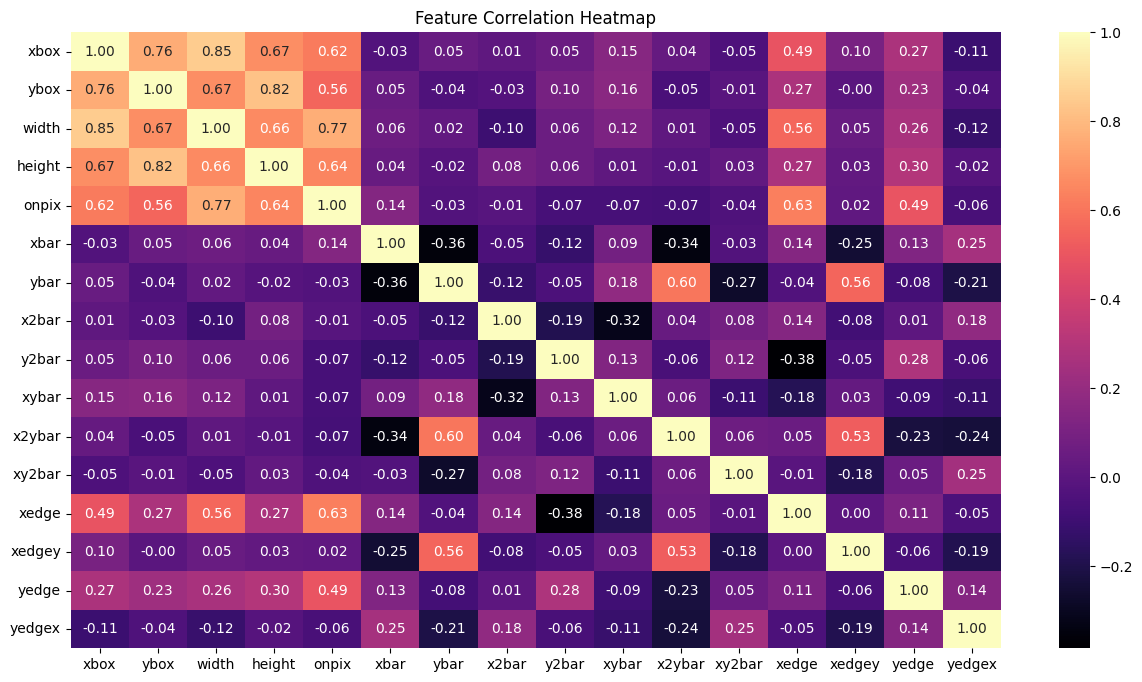

In [11]:
plt.figure(figsize=(15,8))
sns.heatmap(df.drop('letter', axis=1).corr(), 
            cmap='magma', 
            annot=True,fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

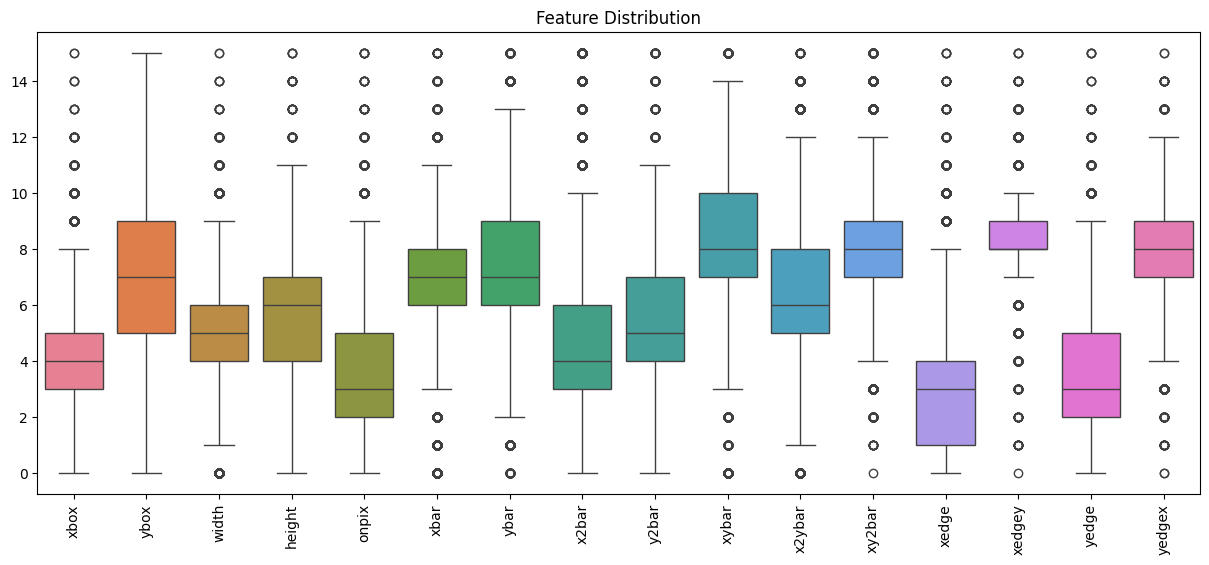

In [12]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df.drop('letter', axis=1))
plt.xticks(rotation=90)
plt.title("Feature Distribution")
plt.show()

In [13]:
#Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['letter'])

print("First 10 encoded values:", y_encoded[:10])
print("Number of classes:", len(np.unique(y_encoded)))

First 10 encoded values: [19  8  3 13  6 18  1  0  9 12]
Number of classes: 26


In [14]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (20000, 16)


In [15]:
# Train-test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16000, 16)
Testing set shape: (4000, 16)


### Model Implementation

In [16]:
# Build Baseline ANN Model
model = Sequential()

# Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(16,)))

# Output Layer (26 classes)
model.add(Dense(26, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,778 (10.85 KB)

 Trainable params: 2,778 (10.85 KB)

 Non-trainable params: 0 (0.00 B)

- The model contains 1 hidden layer with 64 neurons (ReLU activation) and an output layer with 26 neurons (Softmax).
- Total trainable parameters: 2,778.
- This serves as the baseline ANN model for comparison with the tuned model later.

In [17]:
# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [18]:
history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2,callbacks=[early_stopping],verbose=1)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4617 - loss: 2.0932 - val_accuracy: 0.6794 - val_loss: 1.3518
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7218 - loss: 1.1021 - val_accuracy: 0.7453 - val_loss: 0.9744
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7686 - loss: 0.8629 - val_accuracy: 0.7747 - val_loss: 0.8275
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7927 - loss: 0.7458 - val_accuracy: 0.8006 - val_loss: 0.7347
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8097 - loss: 0.6681 - val_accuracy: 0.8091 - val_loss: 0.6676
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8249 - loss: 0.6099 - val_accuracy: 0.8209 - val_loss: 0.6135
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8373 - loss: 0.5617 - val_accuracy: 0.8328 - val_loss: 0.5688
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8508 - loss: 0.5200 - val_accuracy: 0.

In [19]:
# Evaluate the Model
evaluation = model.evaluate(X_test, y_test)
print(f'Test Loss: {evaluation[0]}, Test Accuracy: {evaluation[1]}')


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9355 - loss: 0.2112
Test Loss: 0.2112257480621338, Test Accuracy: 0.9355000257492065


In [20]:
# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step
Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       149
           1       0.84      0.94      0.89       153
           2       0.96      0.94      0.95       137
           3       0.89      0.89      0.89       156
           4       0.94      0.94      0.94       141
           5       0.90      0.92      0.91       140
           6       0.96      0.93      0.95       160
           7       0.90      0.80      0.85       144
           8       0.98      0.90      0.94       146
           9       0.95      0.96      0.96       149
          10       0.86      0.93      0.90       130
          11       0.96      0.94      0.95       155
          12       0.95      0.94      0.95       168
          13       0.90      0.92      0.91       151
          14       0.90      0.95      0.93       145
          15       0.97      0.94      0.95       173
          16  

- The ANN model achieved an overall accuracy of 93%.
- The macro-average precision, recall, and F1-score are all 0.93, indicating balanced performance across all 26 alphabet classes.
- Most classes achieve F1-scores above 0.90, demonstrating strong classification capability with minimal class bias.

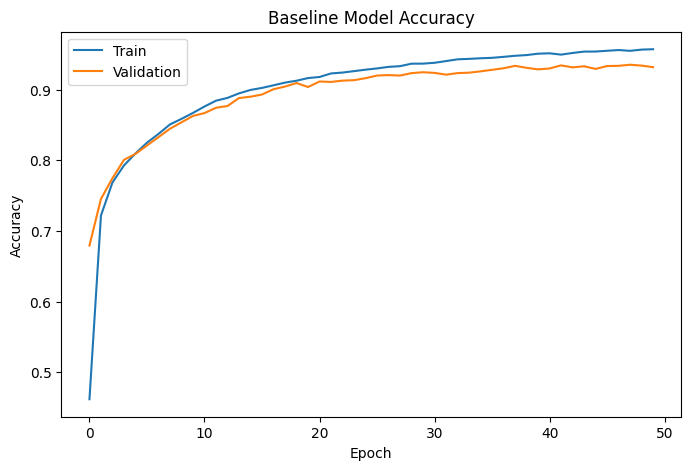

In [21]:
# Baseline Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Baseline Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

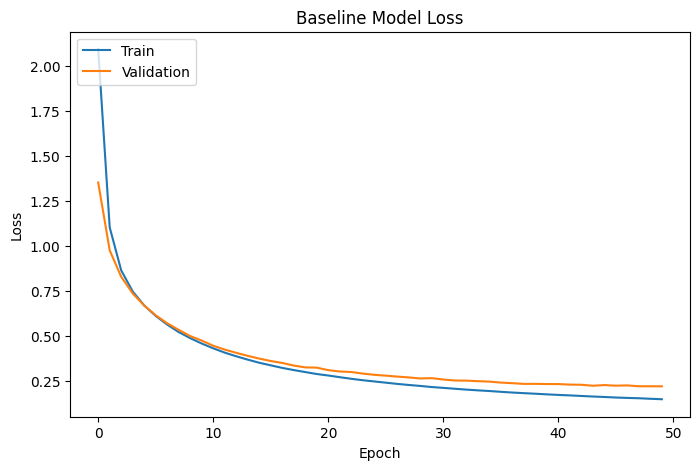

In [22]:
#Baseline Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Baseline Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

- The baseline model shows a steady increase in training and validation accuracy with minimal gap between them, indicating good generalization.
- The loss curves decrease smoothly without divergence, suggesting that the model does not suffer from overfitting and performs consistently on unseen data.

### 3. Hyperparameter Tuning

In [23]:
# Build Tuned ANN Model
tuned_model = Sequential()

# Hidden Layer 1
tuned_model.add(Dense(128, activation='relu', input_shape=(16,)))
tuned_model.add(Dropout(0.3))

# Hidden Layer 2
tuned_model.add(Dense(64, activation='relu'))
tuned_model.add(Dropout(0.3))

# Output Layer
tuned_model.add(Dense(26, activation='softmax'))

# Compile Model
tuned_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tuned_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,122 (47.35 KB)

 Trainable params: 12,122 (47.35 KB)

 Non-trainable params: 0 (0.00 B)

- The tuned ANN model includes two hidden layers with 128 and 64 neurons respectively, along with Dropout regularization.
- The total number of trainable parameters increased from 2,778 to 12,122, enhancing model capacity while controlling overfitting.

In [24]:
history_tuned = tuned_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4026 - loss: 2.0615 - val_accuracy: 0.6856 - val_loss: 1.1746
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6123 - loss: 1.2597 - val_accuracy: 0.7431 - val_loss: 0.9006
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6730 - loss: 1.0526 - val_accuracy: 0.7825 - val_loss: 0.7661
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7009 - loss: 0.9522 - val_accuracy: 0.8000 - val_loss: 0.6858
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7304 - loss: 0.8652 - val_accuracy: 0.8219 - val_loss: 0.6197


In [25]:
tuned_loss, tuned_accuracy = tuned_model.evaluate(X_test, y_test)
print("Tuned Test Accuracy:", tuned_accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6930 - loss: 1.1402
Tuned Test Accuracy: 0.6930000185966492


- The tuned model with additional layers and Dropout regularization resulted in lower performance (68%) compared to the baseline model (93%).
- This suggests that the baseline architecture was already sufficient for this dataset, and increasing complexity led to underfitting due to excessive regularization.

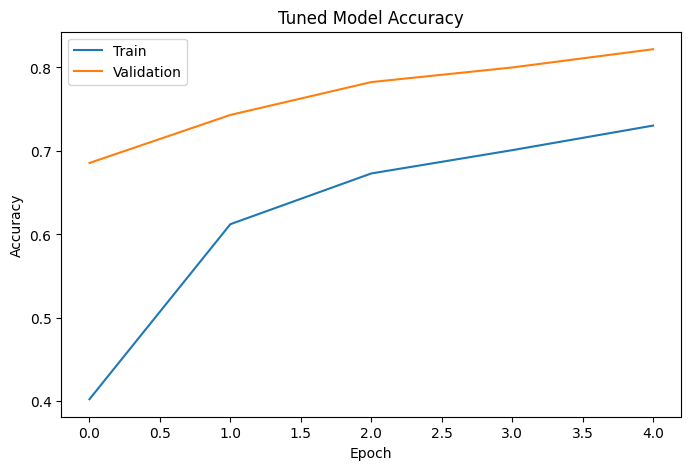

In [26]:
#Tuned Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history_tuned.history['accuracy'])
plt.plot(history_tuned.history['val_accuracy'])
plt.title('Tuned Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

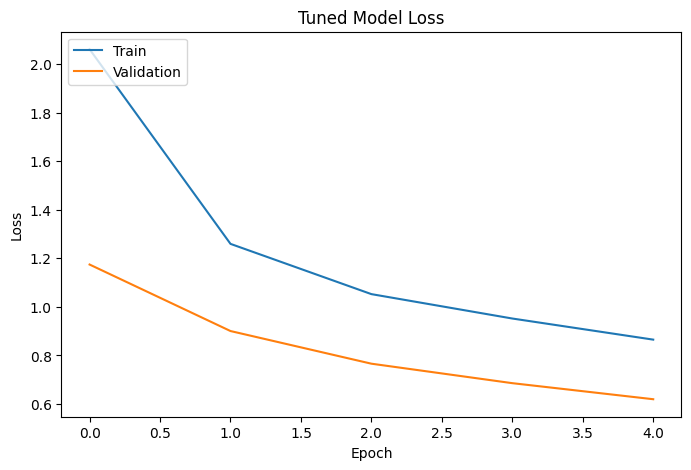

In [27]:
#Tuned Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history_tuned.history['loss'])
plt.plot(history_tuned.history['val_loss'])
plt.title('Tuned Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

- The tuned model shows slower improvement in training accuracy and lower overall performance compared to the baseline model.
- Although validation accuracy increases steadily, it stabilizes at a much lower value (~ 81%) compared to the baseline (~ 93%).
- This indicates that increasing model complexity with additional layers and Dropout led to underfitting and reduced generalization performance.

### Evaluation

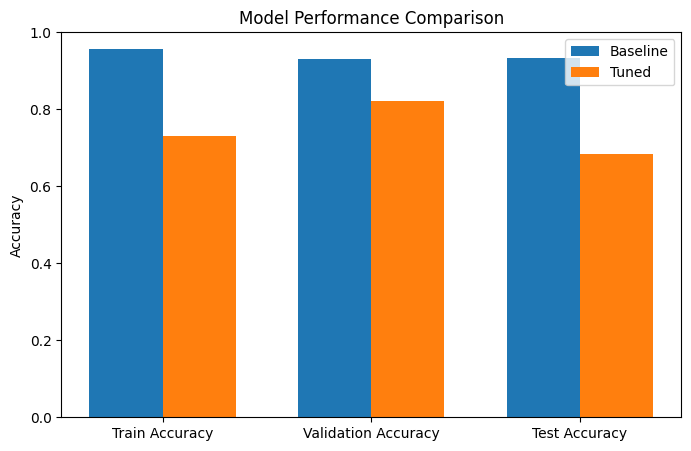

In [28]:
# Showing comparison graphs
comparison = {
    'Baseline': [history.history['accuracy'][-1],history.history['val_accuracy'][-1],0.9325],
    'Tuned': [history_tuned.history['accuracy'][-1],history_tuned.history['val_accuracy'][-1],0.6847]
}

labels = ['Train Accuracy', 'Validation Accuracy', 'Test Accuracy']

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, comparison['Baseline'], width, label='Baseline')
plt.bar(x + width/2, comparison['Tuned'], width, label='Tuned')

plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

The baseline model consistently outperforms the tuned model across training, validation, and test accuracy, confirming that the simpler architecture generalizes better for this dataset.

### Conclusion

1. In this assignment, an Artificial Neural Network (ANN) was implemented for multi-class alphabet classification. The dataset was preprocessed using label encoding and feature scaling, followed by splitting into training and testing sets.
2. A baseline ANN model with one hidden layer achieved a test accuracy of 93%, demonstrating strong classification performance and good generalization.
3. Hyperparameter tuning was performed by increasing the number of hidden layers and introducing Dropout regularization. However, the tuned model did not improve performance and resulted in lower accuracy.
4. This indicates that the baseline architecture was sufficient for capturing the patterns in the dataset, and increasing model complexity led to reduced performance. Therefore, the baseline ANN model is selected as the final and optimal model for this task.